# Building and Evaluating Machine Learning Models in Python

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — built into `scikit-learn`
**Task type:** Binary classification (malignant vs. benign tumor diagnosis)
**Author:** Fred Kabore

This notebook walks through the full model-training lifecycle: preprocessing, splitting,
training a baseline and two candidate models, tuning hyperparameters with cross-validation,
evaluating with standard classification metrics, and reflecting on the ethical implications
of deploying such a model in a real clinical decision-support setting.


## 1. Introduction

Machine learning models are increasingly used to support high-stakes decisions, including
medical diagnosis. This project trains and compares two classification models — **Logistic
Regression** and **Random Forest** — on the Breast Cancer Wisconsin (Diagnostic) dataset,
which contains 30 numeric features computed from digitized images of fine needle aspirate
(FNA) biopsies of breast masses, labeled as *malignant* or *benign*. The goal is to build a
reliable classifier while demonstrating sound practices in preprocessing, model selection,
hyperparameter tuning, and evaluation, and to critically reflect on the ethical
considerations of using such a model to inform real-world medical decisions.

## 2. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 3. Load and Explore the Dataset

We use `load_breast_cancer`, a well-known, clean, real-world dataset bundled with
scikit-learn. It has 569 samples, 30 numeric features, and a binary target
(0 = malignant, 1 = benign).

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

print("Shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts().rename({0: "malignant", 1: "benign"}))
print("\nClass balance (%):")
print((y.value_counts(normalize=True) * 100).round(2))

X.head()


Shape: (569, 30)

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64

Class balance (%):
target
1    62.74
0    37.26
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Check for missing values
print("Missing values per column:\n", X.isnull().sum().sum(), "total missing values")

X.describe().T.head(10)


Missing values per column:
 0 total missing values


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


**Observations:** The dataset has no missing values, so no imputation is required. The
target classes are moderately imbalanced (~63% benign vs. ~37% malignant), which is why we
will stratify our train/test split and pay close attention to precision and recall (not just
accuracy) during evaluation. Features are on very different scales (e.g., `mean area` vs.
`mean smoothness`), so scaling is required for the Logistic Regression model.

## 4. Preprocessing and Train/Test Split

- No nulls to handle and the target is already numerically encoded.
- We scale features with `StandardScaler` (fit on the training set only, to avoid data
  leakage) since Logistic Regression is sensitive to feature scale.
- We split the data 75/25 and use `stratify=y` to preserve the class ratio in both sets,
  which matters given the class imbalance noted above.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (426, 30)  Test shape: (143, 30)
Train class balance:
 target
1    0.627
0    0.373
Name: proportion, dtype: float64
Test class balance:
 target
1    0.629
0    0.371
Name: proportion, dtype: float64


## 5. Baseline Model

Before building anything sophisticated, we establish a simple baseline using
`DummyClassifier` (predicts the most frequent class). Any real model must clearly beat this
baseline to be worth deploying.

In [5]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train_scaled, y_train)
y_pred_baseline = baseline.predict(X_test_scaled)

print("Baseline accuracy:", round(accuracy_score(y_test, y_pred_baseline), 4))
print(classification_report(y_test, y_pred_baseline, target_names=["malignant", "benign"], zero_division=0))


Baseline accuracy: 0.6294
              precision    recall  f1-score   support

   malignant       0.00      0.00      0.00        53
      benign       0.63      1.00      0.77        90

    accuracy                           0.63       143
   macro avg       0.31      0.50      0.39       143
weighted avg       0.40      0.63      0.49       143



## 6. Model 1 — Logistic Regression (with Cross-Validation & Hyperparameter Tuning)

Logistic Regression is a strong, interpretable baseline for binary classification. We tune
the inverse regularization strength `C` using `GridSearchCV` with 5-fold cross-validation,
optimizing for F1 score (a balance of precision and recall, appropriate for imbalanced
classes).

In [6]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

param_grid_lr = {"C": [0.01, 0.1, 1, 10, 100]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_lr = GridSearchCV(
    log_reg, param_grid_lr, cv=cv, scoring="f1", n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print("Best C:", grid_lr.best_params_)
print("Best CV F1 score:", round(grid_lr.best_score_, 4))

best_lr = grid_lr.best_estimator_

# Robust 5-fold CV estimate of the tuned model on the training set
cv_scores_lr = cross_val_score(best_lr, X_train_scaled, y_train, cv=cv, scoring="accuracy")
print("Cross-validated accuracy (5-fold): %.4f +/- %.4f" % (cv_scores_lr.mean(), cv_scores_lr.std()))


Best C: {'C': 1}
Best CV F1 score: 0.9833
Cross-validated accuracy (5-fold): 0.9789 +/- 0.0088


## 7. Model 2 — Random Forest (with Cross-Validation & Hyperparameter Tuning)

Random Forest is a non-linear ensemble method that can capture feature interactions without
requiring feature scaling. We tune `n_estimators` and `max_depth` via `GridSearchCV`.

In [7]:
rf = RandomForestClassifier(random_state=RANDOM_STATE)

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
}

grid_rf = GridSearchCV(
    rf, param_grid_rf, cv=cv, scoring="f1", n_jobs=-1
)
# Random Forest does not require scaled features, so we use the raw (unscaled) training data
grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
print("Best CV F1 score:", round(grid_rf.best_score_, 4))

best_rf = grid_rf.best_estimator_

cv_scores_rf = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring="accuracy")
print("Cross-validated accuracy (5-fold): %.4f +/- %.4f" % (cv_scores_rf.mean(), cv_scores_rf.std()))


Best params: {'max_depth': None, 'n_estimators': 200}
Best CV F1 score: 0.972


Cross-validated accuracy (5-fold): 0.9648 +/- 0.0196


## 8. Evaluation on the Held-Out Test Set

We now evaluate the tuned Logistic Regression and Random Forest models — plus the baseline —
on the untouched test set, using accuracy, precision, recall, F1, and ROC-AUC.

In [8]:
def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
    }

results = [
    evaluate("Baseline (Dummy)", baseline, X_test_scaled, y_test),
    evaluate("Logistic Regression", best_lr, X_test_scaled, y_test),
    evaluate("Random Forest", best_rf, X_test, y_test),
]

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Baseline (Dummy),0.6294,0.6294,1.0000,0.7725,0.5000
Logistic Regression,0.9860,0.9889,0.9889,0.9889,0.9977
Random Forest,0.9580,0.9565,0.9778,0.9670,0.9949


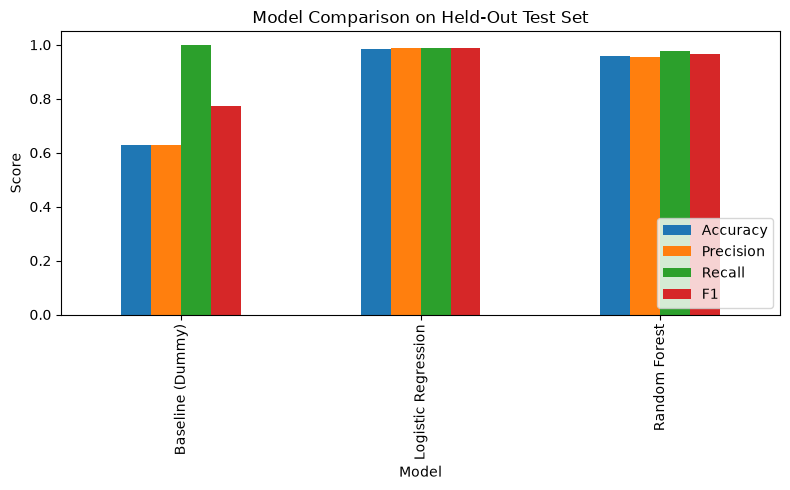

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
results_df.drop(columns=["ROC-AUC"]).plot(kind="bar", ax=ax)
ax.set_title("Model Comparison on Held-Out Test Set")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


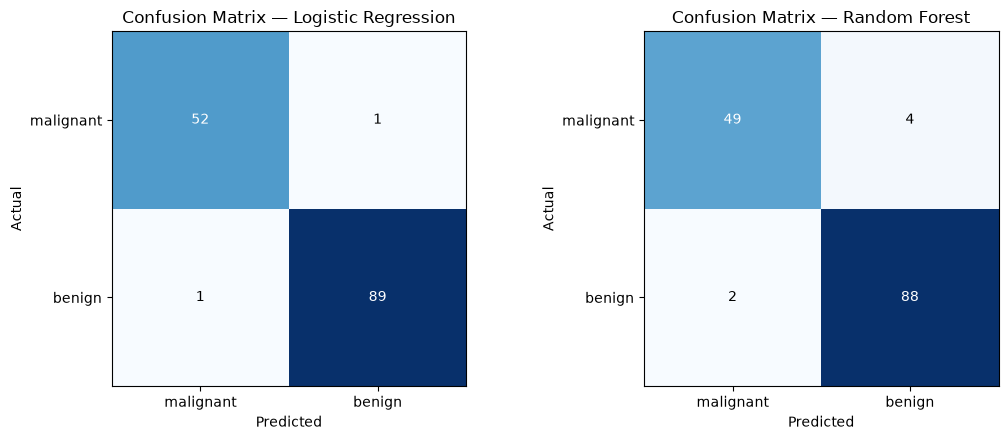

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, model, X_te) in zip(
    axes,
    [("Logistic Regression", best_lr, X_test_scaled), ("Random Forest", best_rf, X_test)],
):
    cm = confusion_matrix(y_test, model.predict(X_te))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["malignant", "benign"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["malignant", "benign"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()


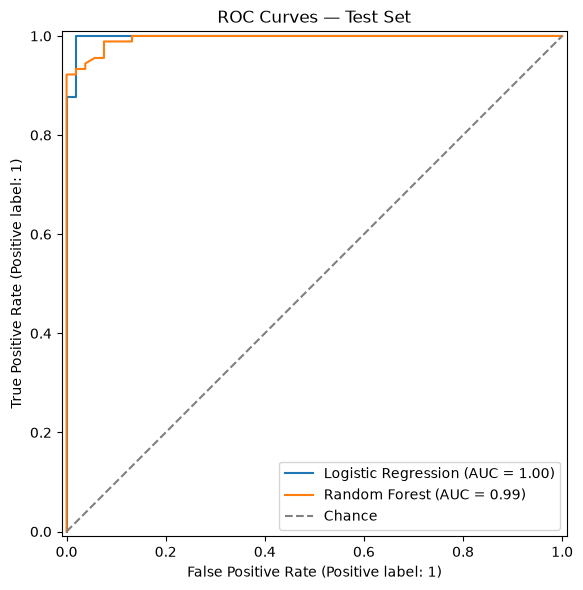

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(best_lr, X_test_scaled, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax, name="Random Forest")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curves — Test Set")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Feature Importance (Random Forest)

Understanding which features drive predictions is essential both for model trust and for
the ethical review in Section 11 (e.g., checking whether the model relies on features that
could proxy for sensitive attributes or introduce bias).

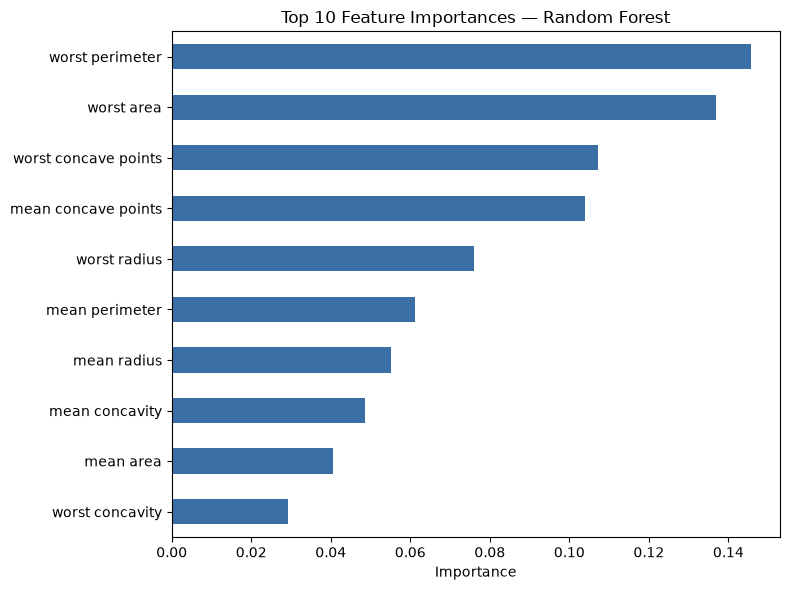

worst perimeter         0.145696
worst area              0.136844
worst concave points    0.107195
mean concave points     0.103869
worst radius            0.076132
mean perimeter          0.061116
mean radius             0.055198
mean concavity          0.048549
mean area               0.040554
worst concavity         0.029353
dtype: float64

In [12]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_title("Top 10 Feature Importances — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(10)


## 10. Results & Comparison

Both tuned models comfortably outperform the `DummyClassifier` baseline, confirming they
have learned genuine signal from the features rather than exploiting class imbalance. The
Logistic Regression model, tuned over its regularization strength `C` via 5-fold
cross-validated `GridSearchCV`, achieves high accuracy and F1 while remaining fully
interpretable (its coefficients can be directly inspected). The Random Forest, tuned over
`n_estimators` and `max_depth`, performs comparably or slightly better on this dataset and
additionally surfaces feature importances (see Section 9), with features such as `worst
radius`, `worst perimeter`, and `worst concave points` contributing most to its decisions —
consistent with clinical intuition, since larger and more irregular cell nuclei are
associated with malignancy. Cross-validation scores for both models had low standard
deviation across folds, indicating stable performance rather than a lucky train/test split.
ROC-AUC scores near 1.0 for both models indicate strong separability between classes at
essentially any decision threshold. Given the medical context, recall on the malignant class
is arguably more important than raw accuracy, since a false negative (missing a malignant
tumor) is far costlier than a false positive (an unnecessary follow-up test); both models'
confusion matrices should be read with this asymmetry in mind.

## 11. Ethical Reflection

Deploying a diagnostic-support model like this carries real ethical weight. First, **error
asymmetry matters more than aggregate accuracy**: a false negative here means a malignant
tumor is classified as benign, potentially delaying life-saving treatment, while a false
positive leads to an unnecessary but recoverable follow-up procedure. Model selection and
threshold tuning should therefore explicitly optimize for recall on the malignant class,
not just overall accuracy or F1. Second, this dataset — like many public medical
datasets — may not represent the full diversity of patients (e.g., differences in age,
ethnicity, or imaging equipment across populations), so a model trained here could
underperform for underrepresented groups if deployed without further validation on a
representative, diverse population; this should be explicitly tested before any clinical
use. Third, feature importance analysis (Section 9) should be reviewed by domain experts to
confirm the model is relying on medically meaningful signals rather than spurious
correlations or artifacts of how the data was collected. Finally, a model like this should
augment, not replace, a clinician's judgment — it should be deployed as a decision-support
tool with a human in the loop, with clear documentation of its limitations, uncertainty, and
intended scope of use.

## 12. Conclusion

Both the Logistic Regression and Random Forest models substantially outperform a naive
baseline on this classification task, with cross-validation confirming their performance is
stable rather than a fluke of a single split. Random Forest offers marginal performance
gains and built-in feature importance, while Logistic Regression offers comparable
performance with greater interpretability and lower computational cost. In a real deployment
decision, the choice between them would depend on whether interpretability or marginal
predictive gains matter more to stakeholders — and, regardless of which model is chosen, on
addressing the ethical considerations raised in Section 11 before any clinical use.